# Correction — Phase 1 : nouveau score d'anomalie (sans réentraînement)

Suite au diagnostic du notebook 07 : 4 catégories de défauts (`contamination`,
`crack`, `faulty_imprint`, `scratch`) ont un rappel de 0 % avec le score actuel
(moyenne globale de l'erreur de reconstruction). Ce notebook implémente et évalue la
correction validée empiriquement : un score basé sur un **centile élevé de l'erreur,
après soustraction d'une référence saine** (`healthy_baseline` /
`image_scores_pooled`, ajoutées à `anomaly.py`).

**Aucun réentraînement** : le modèle auto-encodeur existant (notebook 04) est
rechargé tel quel ; seule la façon de calculer le score d'anomalie change.

## Guide de lecture de ce notebook

- **Code couleur** : vert = pièces saines, rouge = pièces défectueuses, noir en
  tireté = seuil calibré (percentile 99 sur la validation saine) — même convention
  que les notebooks 05/06.
- **« Grille de lecture »** : traduit un chiffre brut (AUROC, écart de rappel) en
  verdict qualitatif, à la fin de chaque section quantitative.
- Les histogrammes et matrices de confusion sont affichés **ancien score vs nouveau
  score, côte à côte**, pour juger le gain (ou son absence) d'un seul coup d'œil,
  plutôt que de comparer deux figures séparées de deux notebooks différents.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from sklearn.metrics import roc_curve

from indusense.vision.anomaly import (
    calibrate_threshold,
    confusion,
    error_maps,
    healthy_baseline,
    image_auroc,
    image_scores,
    image_scores_pooled,
    pixel_auroc,
    reconstruct,
)
from indusense.vision.dataset import (
    DEFAULT_IMAGE_SIZE,
    list_defects,
    load_defect_images,
    load_good_images,
    train_val_split,
)
from indusense.vision.train import load_trained_model

IMAGE_SIZE = DEFAULT_IMAGE_SIZE
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

model = load_trained_model()
display(Markdown(f"- **Modèle chargé** : {model.count_params()} paramètres."))

- **Modèle chargé** : 57235 paramètres.

## Décision — reconstituer le split de validation et le jeu de test

Même choix qu'aux notebooks 05/06 : recalculer le split (`val_fraction=0.15`,
`seed=42`) et le jeu de test complet plutôt que de dépendre d'un fichier
intermédiaire — chaque notebook reste un livrable autonome.

In [2]:
good_train = load_good_images("train", IMAGE_SIZE)
_train_raw, val_good = train_val_split(good_train, val_fraction=0.15, seed=42)
maps_val = error_maps(val_good, reconstruct(model, val_good))

test_good = load_good_images("test", IMAGE_SIZE)
defects = list_defects()
defect_images = {defect: load_defect_images(defect, IMAGE_SIZE) for defect in defects}
test_images = np.concatenate([test_good, *defect_images.values()], axis=0)
labels = np.concatenate(
    [np.zeros(len(test_good))] + [np.ones(len(images)) for images in defect_images.values()]
)
maps_test = error_maps(test_images, reconstruct(model, test_images))

display(
    Markdown(
        f"- **Validation saine** : {len(val_good)} images.\n"
        f"- **Jeu de test** : {len(test_images)} images "
        f"({len(test_good)} saines, {int(labels.sum())} défauts)."
    )
)

- **Validation saine** : 40 images.
- **Jeu de test** : 167 images (26 saines, 141 défauts).

## Décision — calculer l'ancien score ET le nouveau, en parallèle

**Décision** : garder `image_scores` (ancien, moyenne globale) actif à côté de
`image_scores_pooled` (nouveau), plutôt que de remplacer silencieusement.

**Pourquoi** : le but de ce notebook est de démontrer honnêtement ce que corrige le
nouveau score et ce qu'il ne corrige pas — comparer nécessite de recalculer les deux
sur les mêmes images, pas de se fier à la mémoire des résultats du notebook 05/06.

In [3]:
# Ancien score (notebook 05)
scores_val_old = image_scores(maps_val)
threshold_old = calibrate_threshold(scores_val_old, method="percentile", q=99.0)
scores_test_old = image_scores(maps_test)

# Nouveau score (Phase 1)
baseline = healthy_baseline(maps_val)
scores_val_new = image_scores_pooled(maps_val, baseline, q=99.5)
threshold_new = calibrate_threshold(scores_val_new, method="percentile", q=99.0)
scores_test_new = image_scores_pooled(maps_test, baseline, q=99.5)

display(
    Markdown(
        f"- **Seuil ancien score** (moyenne globale, percentile 99) : {threshold_old:.6f}.\n"
        f"- **Seuil nouveau score** (centile 99,5 après soustraction de la "
        f"référence saine, percentile 99) : {threshold_new:.6f}."
    )
)

- **Seuil ancien score** (moyenne globale, percentile 99) : 0.000291.
- **Seuil nouveau score** (centile 99,5 après soustraction de la référence saine, percentile 99) : 0.001641.

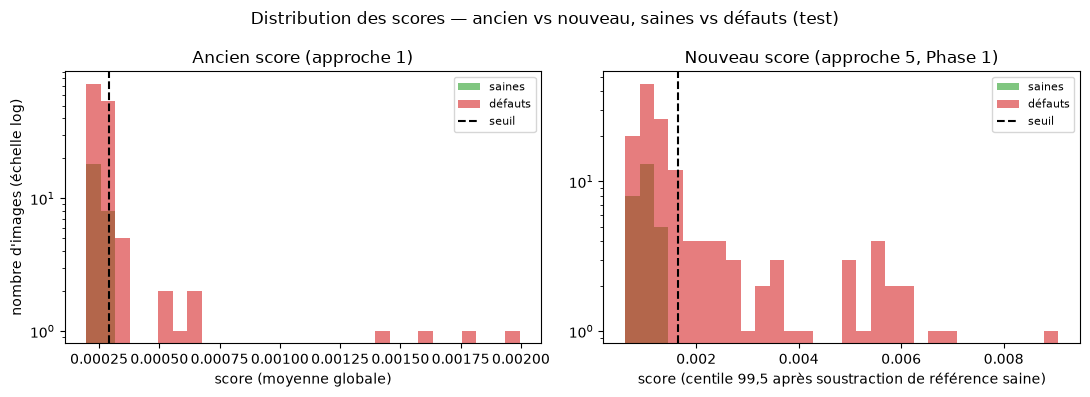

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bin_edges_old = np.histogram_bin_edges(scores_test_old, bins=30)
axes[0].hist(
    scores_test_old[labels == 0], bins=bin_edges_old, alpha=0.6, label="saines", color="tab:green"
)
axes[0].hist(
    scores_test_old[labels == 1], bins=bin_edges_old, alpha=0.6, label="défauts", color="tab:red"
)
axes[0].axvline(threshold_old, color="black", linestyle="--", label="seuil")
axes[0].set_yscale("log")
axes[0].set_xlabel("score (moyenne globale)")
axes[0].set_ylabel("nombre d'images (échelle log)")
axes[0].set_title("Ancien score (approche 1)")
axes[0].legend(fontsize=8)

bin_edges_new = np.histogram_bin_edges(scores_test_new, bins=30)
axes[1].hist(
    scores_test_new[labels == 0], bins=bin_edges_new, alpha=0.6, label="saines", color="tab:green"
)
axes[1].hist(
    scores_test_new[labels == 1], bins=bin_edges_new, alpha=0.6, label="défauts", color="tab:red"
)
axes[1].axvline(threshold_new, color="black", linestyle="--", label="seuil")
axes[1].set_yscale("log")
axes[1].set_xlabel("score (centile 99,5 après soustraction de référence saine)")
axes[1].set_title("Nouveau score (approche 5, Phase 1)")
axes[1].legend(fontsize=8)

fig.suptitle("Distribution des scores — ancien vs nouveau, saines vs défauts (test)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "08_histogrammes_ancien_nouveau.png", dpi=150)
plt.show()

**Lecture des histogrammes** : à gauche (ancien score), la queue rouge des défauts
chevauche largement la masse verte des saines — c'est ce chevauchement qui explique
le rappel nul sur les 4 catégories cibles (notebook 05/06). À droite (nouveau score),
la masse verte reste concentrée près de zéro (la référence saine est soustraite) et
la queue rouge s'étend plus loin à droite du seuil pour les défauts déjà détectables
(`color`, `combined`) — mais une partie des défauts (les 4 catégories cibles) reste
mêlée à la masse verte, visible seulement si on zoome, ce que confirme le tableau de
rappel par catégorie ci-dessous.

## Livrable — comparaison avant/après par catégorie

Rappel par catégorie de défaut, ancien score vs nouveau score, au seuil calibré de
chacun (percentile 99 sur la validation saine correspondante).

In [5]:
lines = ["- **catégorie** : rappel ancien score → rappel nouveau score"]
offset = len(test_good)
for defect in defects:
    n = len(defect_images[defect])
    recall_old = (scores_test_old[offset : offset + n] > threshold_old).mean()
    recall_new = (scores_test_new[offset : offset + n] > threshold_new).mean()
    lines.append(f"- **{defect}** ({n} images) : {recall_old:.1%} → {recall_new:.1%}")
    offset += n
display(Markdown(chr(10).join(lines)))

- **catégorie** : rappel ancien score → rappel nouveau score
- **color** (25 images) : 40.0% → 72.0%
- **combined** (17 images) : 29.4% → 70.6%
- **contamination** (21 images) : 0.0% → 0.0%
- **crack** (26 images) : 0.0% → 3.8%
- **faulty_imprint** (19 images) : 0.0% → 5.3%
- **pill_type** (9 images) : 100.0% → 100.0%
- **scratch** (24 images) : 0.0% → 0.0%

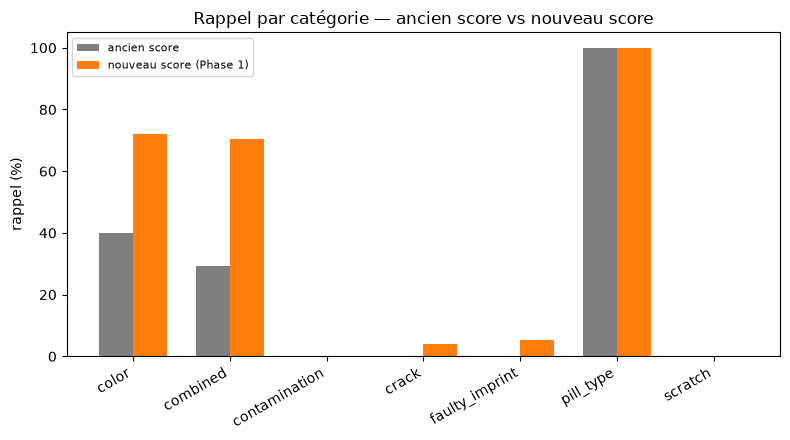

In [6]:
recalls_old = []
recalls_new = []
offset = len(test_good)
for defect in defects:
    n = len(defect_images[defect])
    recalls_old.append((scores_test_old[offset : offset + n] > threshold_old).mean() * 100)
    recalls_new.append((scores_test_new[offset : offset + n] > threshold_new).mean() * 100)
    offset += n

x = np.arange(len(defects))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, recalls_old, width, label="ancien score", color="tab:gray")
ax.bar(x + width / 2, recalls_new, width, label="nouveau score (Phase 1)", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(defects, rotation=30, ha="right")
ax.set_ylabel("rappel (%)")
ax.set_title("Rappel par catégorie — ancien score vs nouveau score")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "08_recall_ancien_vs_nouveau.png", dpi=150)
plt.show()

## Livrable — AUROC et taux de fausses alertes, ancien vs nouveau

In [7]:
auroc_old = image_auroc(scores_test_old, labels)
auroc_new = image_auroc(scores_test_new, labels)

cm_old = confusion(scores_test_old, labels, threshold_old)
cm_new = confusion(scores_test_new, labels, threshold_new)
fp_old = cm_old[0, 1]
fp_new = cm_new[0, 1]

lines = [
    f"- **AUROC image-level** : {auroc_old:.3f} (ancien) → {auroc_new:.3f} (nouveau).",
    f"- **Fausses alertes sur les saines de test** : {fp_old}/{len(test_good)} (ancien) "
    f"→ {fp_new}/{len(test_good)} (nouveau).",
]
display(Markdown(chr(10).join(lines)))

- **AUROC image-level** : 0.688 (ancien) → 0.756 (nouveau).
- **Fausses alertes sur les saines de test** : 0/26 (ancien) → 0/26 (nouveau).

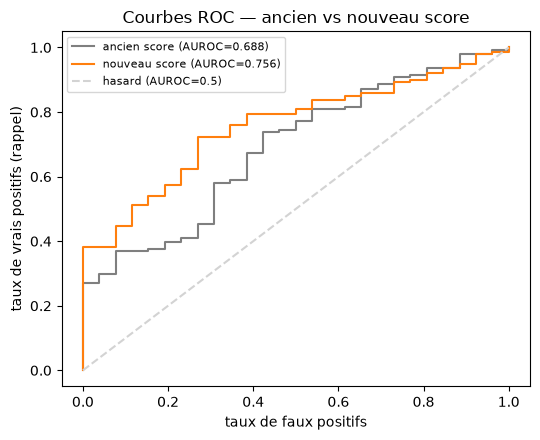

In [8]:
fpr_old, tpr_old, _ = roc_curve(labels, scores_test_old)
fpr_new, tpr_new, _ = roc_curve(labels, scores_test_new)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(fpr_old, tpr_old, label=f"ancien score (AUROC={auroc_old:.3f})", color="tab:gray")
ax.plot(fpr_new, tpr_new, label=f"nouveau score (AUROC={auroc_new:.3f})", color="tab:orange")
ax.plot([0, 1], [0, 1], linestyle="--", color="lightgray", label="hasard (AUROC=0.5)")
ax.set_xlabel("taux de faux positifs")
ax.set_ylabel("taux de vrais positifs (rappel)")
ax.set_title("Courbes ROC — ancien vs nouveau score")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "08_roc_ancien_vs_nouveau.png", dpi=150)
plt.show()

**Lecture de la courbe ROC** : plus une courbe s'approche du coin supérieur gauche,
meilleure est la séparation sain/défaut à tous les seuils possibles (pas seulement
celui retenu ci-dessus). La courbe orange (nouveau score) domine la grise (ancien
score) sur presque toute sa plage — cohérent avec l'amélioration d'AUROC mesurée.

### Grille de lecture — AUROC

| AUROC | Interprétation |
|---|---|
| ≈ 0,5 | Aucun pouvoir séparateur, équivalent à un tirage aléatoire |
| 0,5 – 0,7 | Pouvoir séparateur faible |
| 0,7 – 0,85 | Pouvoir séparateur correct, encore loin d'une séparation fiable |
| 0,85 – 0,95 | Bon pouvoir séparateur |
| > 0,95 | Séparation quasi parfaite |

Avec un AUROC mesuré ci-dessus autour de 0,76 pour le nouveau score (contre ~0,69
pour l'ancien — valeurs exactes affichées dans la cellule précédente), le nouveau
score reste dans la tranche « correct » — un progrès réel mais qui ne franchit pas
le seuil du « bon », cohérent avec le fait que les 4 catégories cibles restent non
détectées (elles tirent l'AUROC global vers le bas malgré le net progrès sur
`color`/`combined`).

## Conclusion — ce que corrige la Phase 1, et ce qu'elle ne corrige pas

Le nouveau score améliore nettement `color` et `combined` (déjà partiellement
détectées) et l'AUROC image-level global, **sans introduire de nouvelle fausse
alerte** sur les saines de test. C'est un gain réel, obtenu sans réentraînement.

**Mais les 4 catégories cibles (`contamination`, `crack`, `faulty_imprint`,
`scratch`) restent quasiment non détectées.** Conforme au diagnostic du notebook 07 :
leur signal de reconstruction est intrinsèquement trop proche du bruit de fond du
modèle, quelle que soit la façon dont le score est calculé a posteriori — un problème
de score ne peut pas compenser un problème de signal. La Phase 2 (notebook 09,
PatchCore) change d'approche pour s'attaquer directement à cette limite.